# 3. Post Processing 

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [65]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from scipy.ndimage import median_filter
from scipy.stats import binned_statistic

# PlatoSim libraries
import platosim.utilities as ut
from platosim.hpc          import HPC
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [64]:
# Global paths
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
sdir = path / 'simulations'
fdir = path / 'figures'

---
## Run simulations locally
---

In [67]:
# Directory to store and load simulations 
odir = f'{path}/simulations/tests/spikey_mag16_nocon_cadence600'

In [ ]:
# # Parse arguments
# varfile = f'{path}/input/varsource_spikey.txt'
# kwargs = f'--seed 12345 --cadence 600 --mag 18 --varfile {varfile} -w'

# # Parse arguments
# hpc = HPC('smbhb', cpus=6)
# hpc.run(script='platonium', param_file='cluster_ncam.data', kwargs=kwargs) 

### Quick look

In [68]:
# Load light curves
lcs = LightCurve(odir, mode="multi")
files = lcs.files(suffix='hdf5')
len(files)

384

<IPython.core.display.Javascript object>


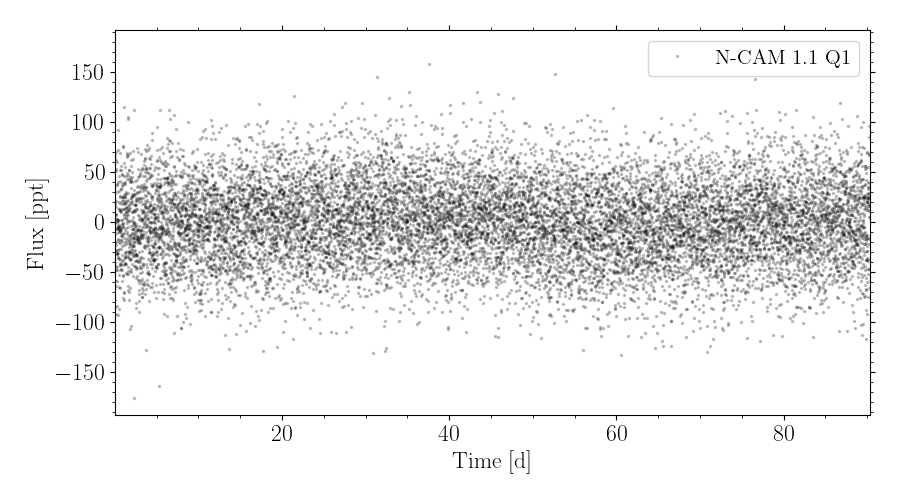

In [69]:
# Show first light curve
lc = LightCurve(files[0], mode="single")
lc.plot(flux_unit='ppt');

<IPython.core.display.Javascript object>


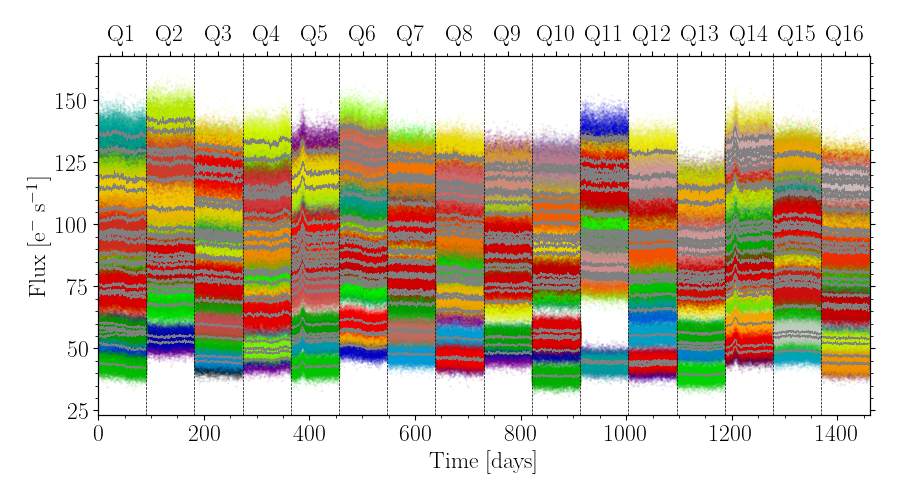

In [70]:
fig, ax = lcs.plot_multi(suffix='hdf5', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5));

### Test single camera light curve

In [72]:
# Load light curves of a single camera
lcs = LightCurve(odir, mode="multi")
files = lcs.files('hdf5', group=1, camera=1)
len(files)

16

In [73]:
# Merge all quarters
df0 = pd.DataFrame()
df1 = pd.DataFrame()
for f in files:
    lc = LightCurve(f)
    df1['time'] = lc.time()
    df1['flux'] = lc.flux(unit='norm')
    df0 = pd.concat([df0, df1])
    
# Deep copy of base flux
df0['flux_base'] = df0.flux

<IPython.core.display.Javascript object>


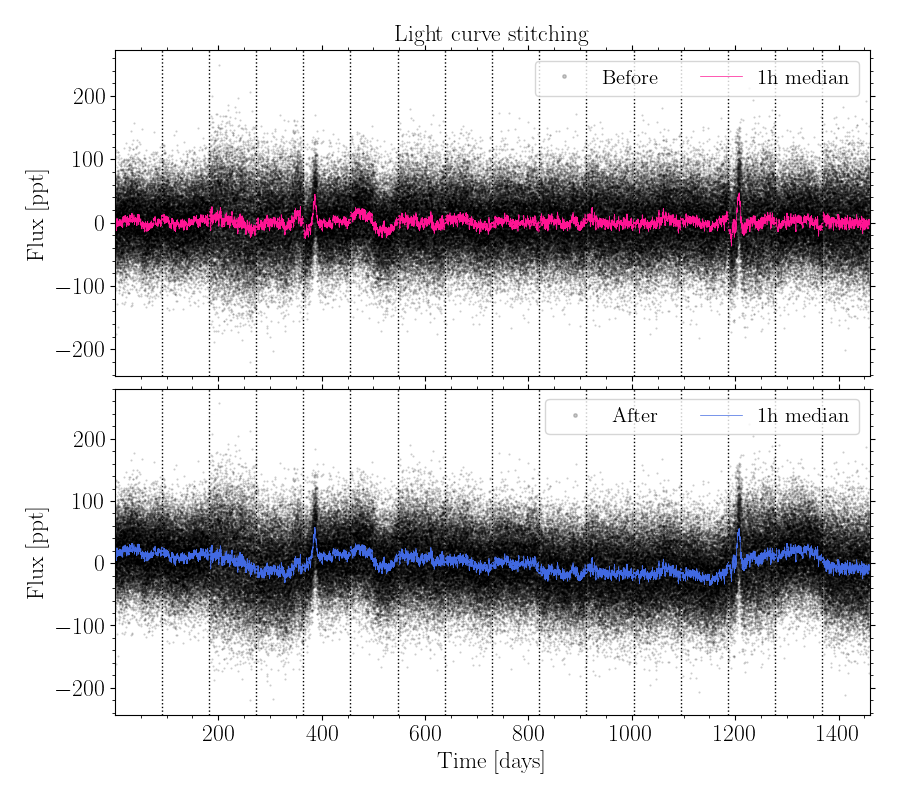

,time,flux,flux_base,flux_stitch
0,12.5,1.007338,1.007338,1.007338
1,612.5,0.914459,0.914459,0.914459
2,1212.5,0.999537,0.999537,0.999537
3,1812.5,0.979385,0.979385,0.979385
4,2412.5,0.959709,0.959709,0.959709


In [74]:
# Stitch the light curve
lc = LightCurve(df0, mode="multi")
df = lc.stitch(method='lowess', segment=10, replace=False, plot=True)
df.head()

<IPython.core.display.Javascript object>


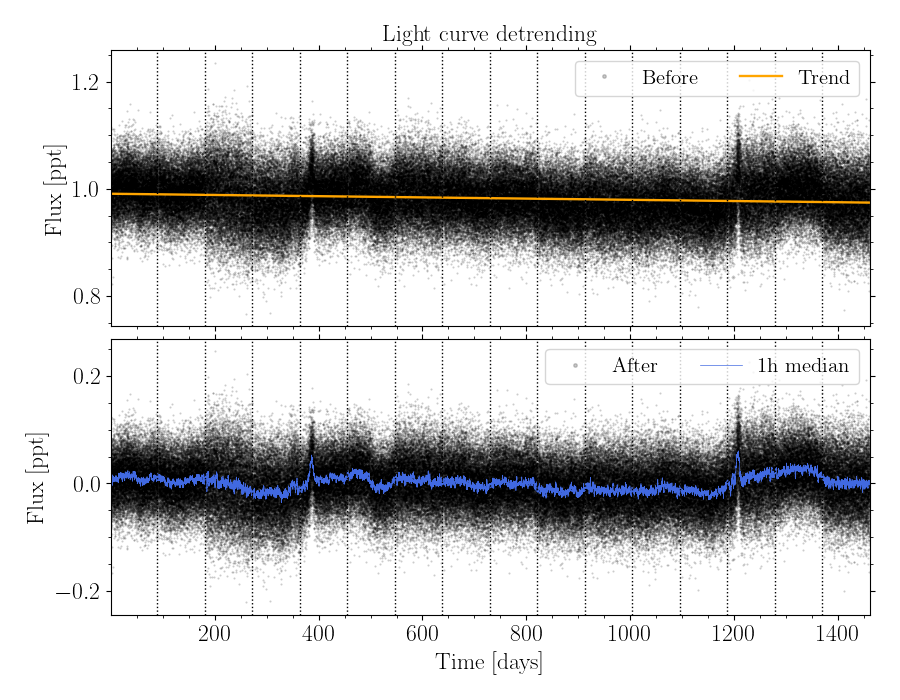

,time,flux,flux_base,flux_stitch,flux_trend,flux_detrend
0,12.5,1.007338,1.007338,1.007338,0.990809,1.000017
1,612.5,0.914459,0.914459,0.914459,0.990809,0.999924
2,1212.5,0.999537,0.999537,0.999537,0.990809,1.000009
3,1812.5,0.979385,0.979385,0.979385,0.990809,0.999989
4,2412.5,0.959709,0.959709,0.959709,0.990808,0.999969


In [75]:
# Detrend light curve
df = lc.detrend(column='flux_stitch', model='poly', poly_degree=1, replace=False, segments=False, plot=True)
df.head()

## Produce final merged light curves

In [60]:
def merge(lcs):
    # Combine the two datasets while reducing each
    dx = pd.DataFrame()
    for g,c in zip(tqdm(range(1,5), bar_format=ut.tqdmBar()), range(1,7)):

        files = lcs.files('hdf5', group=g, camera=c)

        # Merge all quarters
        df0 = pd.DataFrame()
        df1 = pd.DataFrame()
        for f in files:
            lc = LightCurve(f)
            df1['time'] = lc.time()
            df1['flux'] = lc.flux(unit='norm')
            df0 = pd.concat([df0, df1])

        # Deep copy of base flux
        df0['flux_base'] = df0.flux

        # Stitching
        lc = LightCurve(df0, mode="multi")
        df = lc.stitch(method='lowess', segment=10, replace=False, plot=False)

        # Detrending
        df = lc.detrend(column='flux_stitch', model='poly', poly_degree=1, replace=False, segments=False, plot=False)
        df.flux_detrend = (df.flux_detrend-1)*1e6
    
        # Add median filter [1 h]
        df['flux_detrend_med'] = median_filter(df.flux_detrend, 144)
    
        # Merge light curve
        dx = pd.concat([dx, df])

    # Group after timings 
    dx = dx.groupby('time').mean().reset_index()
    
    # Bin data [1 h]
    tbin = 3600
    tdur = dx.time.iloc[-1] - dx.time.iloc[0]
    bins = int(tdur/tbin)
    flux_bin, time_bin, _= binned_statistic(dx.time, dx.flux_detrend, 'median', bins)
    flux_med, time_bin, _= binned_statistic(dx.time, dx.flux_detrend_med, 'median', bins)
    time_bin = time_bin[:-1] + np.diff(time_bin)[0]/2.
    dx = pd.DataFrame({'time':time_bin, 'flux':flux_bin, 'fmed':flux_med})
    
    return dx

### Spikey itself

In [42]:
# Load variable source file and add flux column [ppt]
varfile = f'{path}/varsource/varsource_spikey_fiducial.txt'
dv = pd.read_csv(varfile, sep=' ', names=['time', 'dmag'])
dv['flux'] = (10**(-dv.dmag/2.5) - 1) * 1e3
dv['time'] /= 86400

In [61]:
# Light curve of Spikey
filename = f'{path}/simulations/tests/spikey_mag16_nocon_cadence600'
lcs = LightCurve(filename, mode="multi")
df = merge(lcs)
time = df.time / 86400

100%|██████████████████████████████████████████████████| 4/4 [00:33<00:00,  8.49s/it]                


<IPython.core.display.Javascript object>


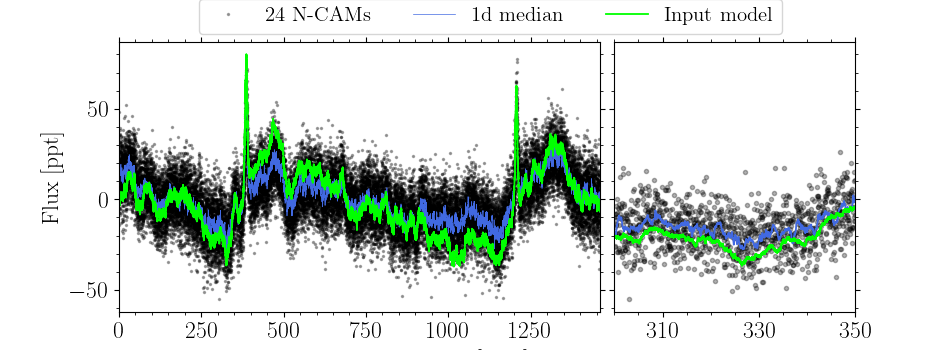

Text(0.5, -0.05, 'Time [days]')

In [62]:
# Plot
# fig, ax = plt.subplots(1, 1, width_ratios=[3, 1], figsize=(9.5, 4.5))
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.04}, figsize=(9.5, 3.5))

ax0.plot(time, df.flux, '.', c='k', ms=3, alpha=0.3, label=r'24 N-CAMs')
ax0.plot(time, df.fmed, '-', c='royalblue', lw=0.5, label='1d median')
ax0.plot(dv.time, dv.flux, '-', c='lime', lw=1.3, label='Input model')
ax0.set_ylabel('Flux [ppt]')
ax0.set_xlim(0, time.max())
# ax0.set_ylim(-180, 190)
ax0.legend(loc='upper right', ncol=3, bbox_to_anchor=(1.4, 1.2))

ax1.plot(time, df.flux, 'o', c='k', ms=3, alpha=0.3, label=r'Spikey observed with 24 N-CAMs')
ax1.plot(time, df.fmed, '-', c='royalblue', lw=1.3)
ax1.plot(dv.time, dv.flux, '-', c='lime', lw=1.3)
ax1.set_xlim(300, 350)
# ax1.set_ylim(-180, 190)
ax1.set_xticks([310, 330, 350])
ax1.set_yticklabels([])

plt.tight_layout()
fig.text(0.5, -0.05, 'Time [days]', ha='center')

# Save figure
# fig.savefig(f'{fdir}/lc_spikey.png', bbox_inches='tight', dpi=300)

### Spikey at different magnitudes

In [10]:
# Load
lcs_mag16 = LightCurve(f'{path}/output/000000001_mag16', mode="multi")
lcs_mag17 = LightCurve(f'{path}/output/000000001_mag17', mode="multi")
lcs_mag18 = LightCurve(f'{path}/output/000000001_mag18', mode="multi")
lcs_mag19 = LightCurve(f'{path}/output/000000001_mag19', mode="multi")

df_mag16 = merge(lcs_mag16)
df_mag17 = merge(lcs_mag17)
df_mag18 = merge(lcs_mag18)
df_mag19 = merge(lcs_mag19)

# Single time array
time = df_mag16.time / 86400

100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.14
100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.15
100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.16
100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.13


<IPython.core.display.Javascript object>


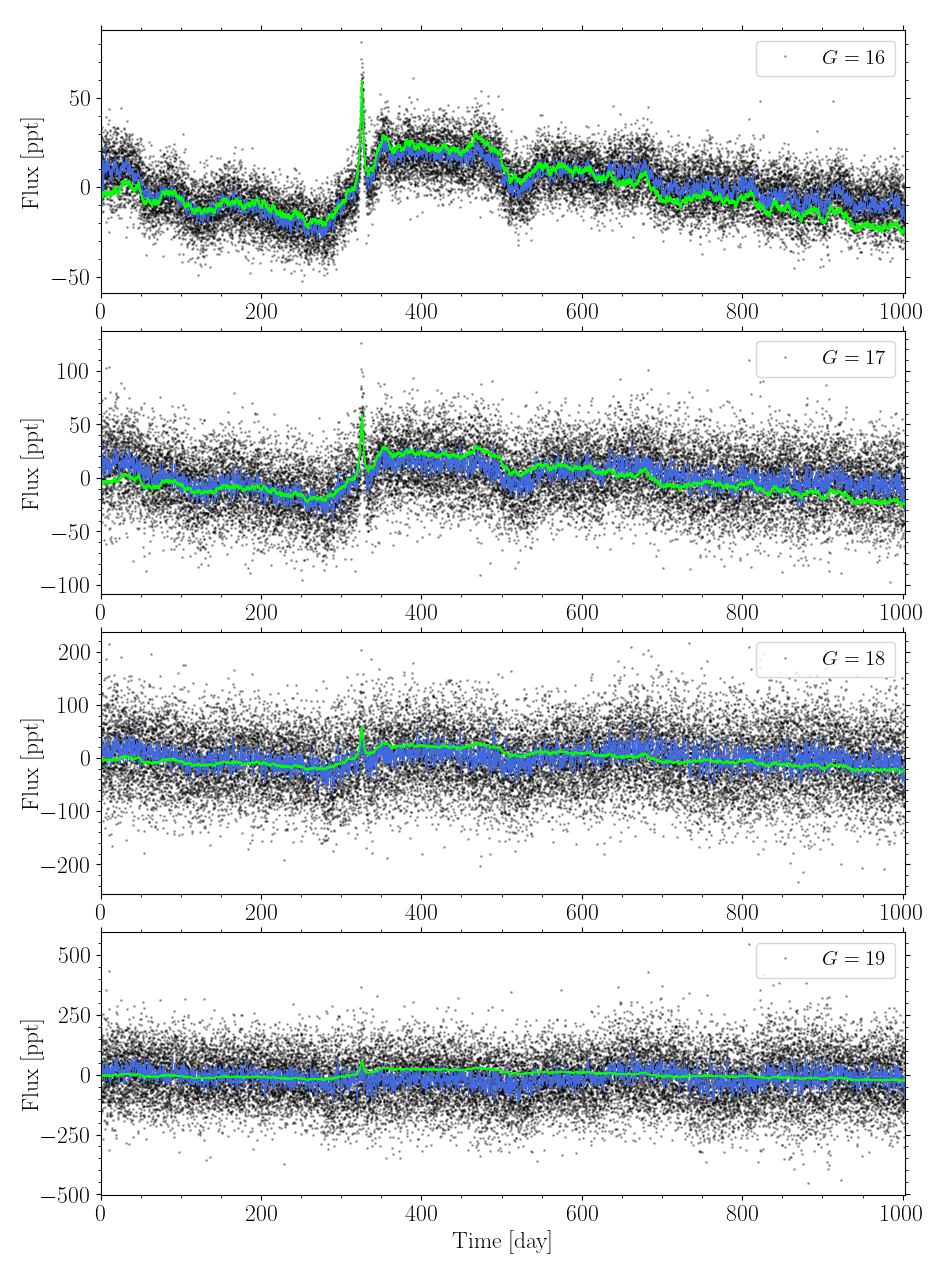

In [36]:
col = 4
fig, ax = plt.subplots(col, 1, figsize=(9.5, col*3.2))

ax[0].plot(time, df_mag16.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=16$')
ax[0].plot(time, df_mag16.fmed, '-', c='royalblue', lw=0.5)
ax[0].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[0].set_ylabel('Flux [ppt]')

ax[1].plot(time, df_mag17.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=17$')
ax[1].plot(time, df_mag17.fmed, '-', c='royalblue', lw=0.5)
ax[1].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[1].set_ylabel('Flux [ppt]')

ax[2].plot(time, df_mag18.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=18$')
ax[2].plot(time, df_mag18.fmed, '-', c='royalblue', lw=0.5)
ax[2].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[2].set_ylabel('Flux [ppt]')

ax[3].plot(time, df_mag19.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=19$')
ax[3].plot(time, df_mag19.fmed, '-', c='royalblue', lw=0.5)
ax[3].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[3].set_ylabel('Flux [ppt]')
ax[3].set_xlabel('Time [day]')

for i in range(col):
    ax[i].set_xlim(0, time.max())
    ax[i].legend(loc='upper right', ncol=3)
    ax[i].get_yaxis().set_label_coords(-0.07, 0.5)
plt.tight_layout(h_pad=0.1);

# Save figure
fig.savefig(f'{fdir}/lc_magnitudes.png', bbox_inches='tight', dpi=300)

### Save reduced light curve

In [1]:
df_mag16.to_feather(f'{path}/lc_Spikey_mag16.ftr')
df_mag17.to_feather(f'{path}/lc_Spikey_mag17.ftr')
df_mag18.to_feather(f'{path}/lc_Spikey_mag18.ftr')
df_mag19.to_feather(f'{path}/lc_Spikey_mag19.ftr')

---
## Plots for thesis
---

### Spikey itself

In [42]:
# Load variable source file and add flux column [ppt]
varfile = f'{path}/varsource/varsource_spikey_fiducial.txt'
dv = pd.read_csv(varfile, sep=' ', names=['time', 'dmag'])
dv['flux'] = (10**(-dv.dmag/2.5) - 1) * 1e3
dv['time'] /= 86400

In [61]:
# Light curve of Spikey
filename = f'{path}/simulations/thesis'
lcs = LightCurve(filename, mode="multi")
df = merge(lcs)
time = df.time / 86400

100%|██████████████████████████████████████████████████| 4/4 [00:33<00:00,  8.49s/it]                


<IPython.core.display.Javascript object>


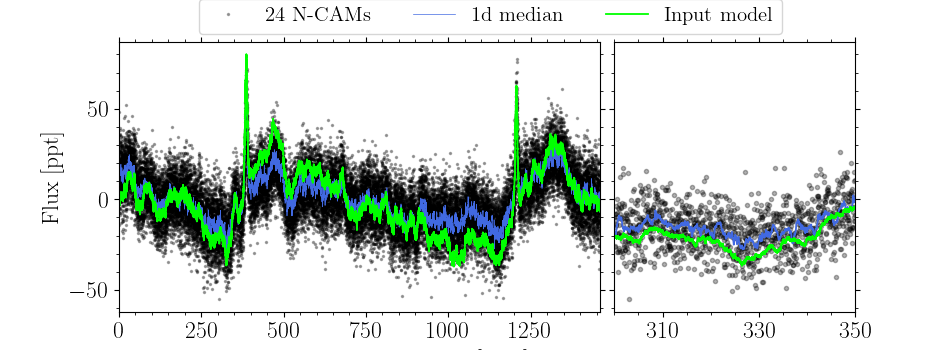

Text(0.5, -0.05, 'Time [days]')

In [62]:
# Plot
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.04}, figsize=(9.5, 3.5))

ax0.plot(time, df.flux, '.', c='k', ms=3, alpha=0.3, label=r'24 N-CAMs')
ax0.plot(time, df.fmed, '-', c='royalblue', lw=0.5, label='1d median')
ax0.plot(dv.time, dv.flux, '-', c='lime', lw=1.3, label='Input model')
ax0.set_ylabel('Flux [ppt]')
ax0.set_xlim(0, time.max())
ax0.set_ylim(-180, 190)
ax0.legend(loc='upper right', ncol=3, bbox_to_anchor=(1.4, 1.2))

ax1.plot(time, df.flux, 'o', c='k', ms=3, alpha=0.3, label=r'Spikey observed with 24 N-CAMs')
ax1.plot(time, df.fmed, '-', c='royalblue', lw=1.3)
ax1.plot(dv.time, dv.flux, '-', c='lime', lw=1.3)
ax1.set_xlim(300, 350)
ax1.set_ylim(-180, 190)
ax1.set_xticks([310, 330, 350])
ax1.set_yticklabels([])

plt.tight_layout()
fig.text(0.5, -0.05, 'Time [days]', ha='center')

# Save figure
fig.savefig(f'{fdir}/lc_spikey.png', bbox_inches='tight', dpi=300)

### Spikey at different magnitudes

In [10]:
# Load
lcs_mag16 = LightCurve(f'{path}/output/000000001_mag16', mode="multi")
lcs_mag17 = LightCurve(f'{path}/output/000000001_mag17', mode="multi")
lcs_mag18 = LightCurve(f'{path}/output/000000001_mag18', mode="multi")
lcs_mag19 = LightCurve(f'{path}/output/000000001_mag19', mode="multi")

df_mag16 = merge(lcs_mag16)
df_mag17 = merge(lcs_mag17)
df_mag18 = merge(lcs_mag18)
df_mag19 = merge(lcs_mag19)

# Single time array
time = df_mag16.time / 86400

100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.14
100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.15
100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.16
100%|██████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.13


<IPython.core.display.Javascript object>


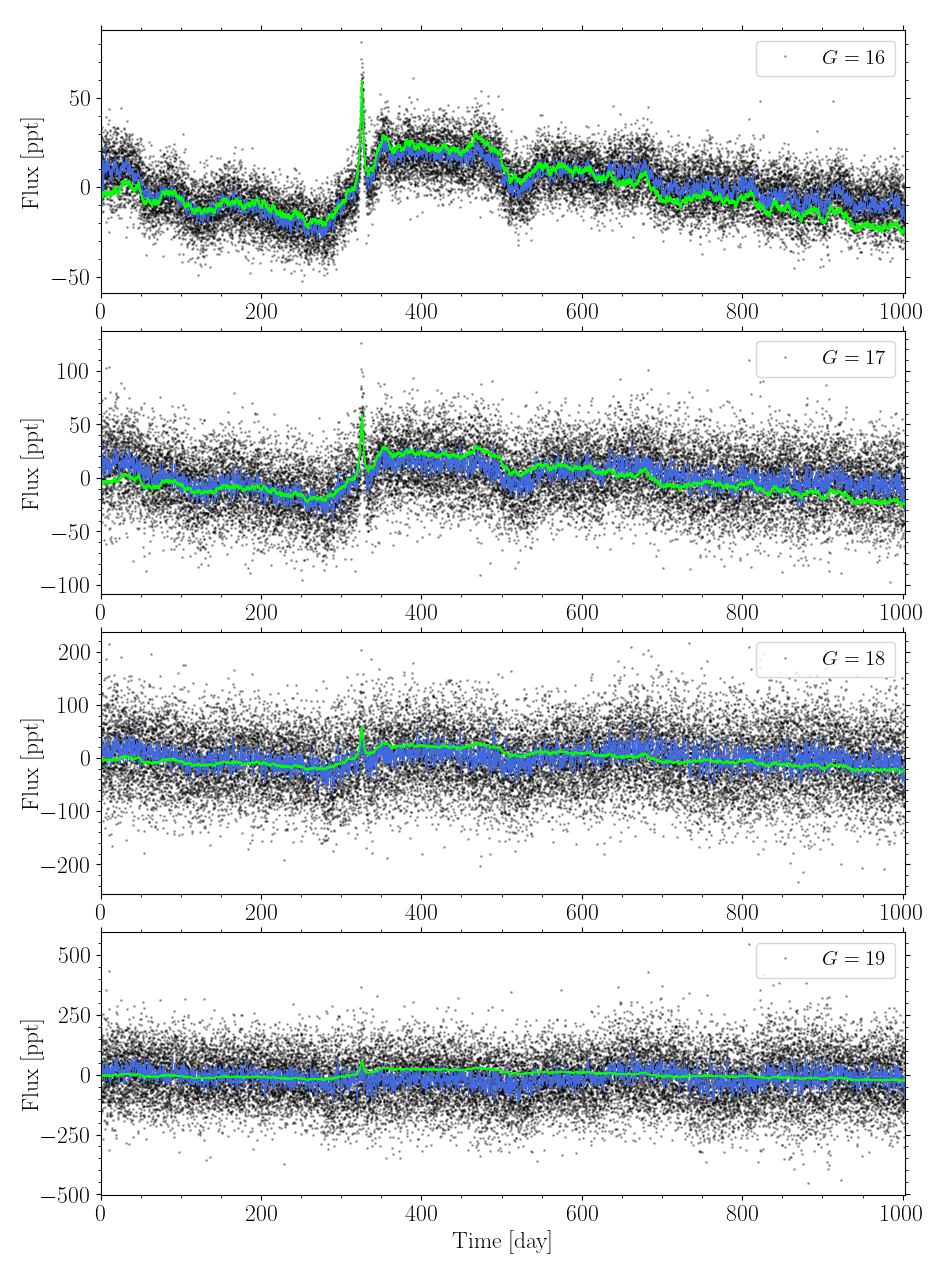

In [36]:
col = 4
fig, ax = plt.subplots(col, 1, figsize=(9.5, col*3.2))

ax[0].plot(time, df_mag16.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=16$')
ax[0].plot(time, df_mag16.fmed, '-', c='royalblue', lw=0.5)
ax[0].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[0].set_ylabel('Flux [ppt]')

ax[1].plot(time, df_mag17.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=17$')
ax[1].plot(time, df_mag17.fmed, '-', c='royalblue', lw=0.5)
ax[1].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[1].set_ylabel('Flux [ppt]')

ax[2].plot(time, df_mag18.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=18$')
ax[2].plot(time, df_mag18.fmed, '-', c='royalblue', lw=0.5)
ax[2].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[2].set_ylabel('Flux [ppt]')

ax[3].plot(time, df_mag19.flux, '.', c='k', ms=2, alpha=0.3, label=r'$G=19$')
ax[3].plot(time, df_mag19.fmed, '-', c='royalblue', lw=0.5)
ax[3].plot(dv.time, dv.flux, '-', c='lime', lw=1)
ax[3].set_ylabel('Flux [ppt]')
ax[3].set_xlabel('Time [day]')

for i in range(col):
    ax[i].set_xlim(0, time.max())
    ax[i].legend(loc='upper right', ncol=3)
    ax[i].get_yaxis().set_label_coords(-0.07, 0.5)
plt.tight_layout(h_pad=0.1);

# Save figure
fig.savefig(f'{fdir}/lc_magnitudes.png', bbox_inches='tight', dpi=300)